In [2]:
# ============================================================
# PHASE 5: SENSOR DEPENDENCY GRAPH
# Goal: Find statistical dependencies between top sensors
# Methods: Partial Correlation + PC Algorithm
# Honest framing: STATISTICAL DEPENDENCY not causal proof
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = r'C:\Users\ASUS\Downloads\capstone\Project\outputs'

X_train_b = pd.read_csv(f'{OUTPUT_DIR}/data/X_train_b.csv')
X_test_b  = pd.read_csv(f'{OUTPUT_DIR}/data/X_test_b.csv')
y_train_b = pd.read_csv(f'{OUTPUT_DIR}/data/y_train_b.csv').squeeze()

top25     = pd.read_csv(f'{OUTPUT_DIR}/data/p4_top25_stable_sensors.csv')
stable_sensors = top25['sensor'].astype(str).tolist()

# Subset to stable sensors only
X_train_top = X_train_b[stable_sensors]
X_test_top  = X_test_b[stable_sensors]

print(f"✅ Data loaded")
print(f"   Stable sensors : {len(stable_sensors)}")
print(f"   Sensors        : {stable_sensors}")
print(f"   X_train_top    : {X_train_top.shape}")

✅ Data loaded
   Stable sensors : 15
   Sensors        : ['59', '519', '460', '33', '0', '426', '205', '129', '468', '420', '485', '510', '563', '21', '155']
   X_train_top    : (1002, 15)


In [3]:
pip install causal-learn networkx

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ============================================================
# STEP 5.1 — PARTIAL CORRELATION NETWORK (Primary method)
# Most stable on small datasets
# Controls for influence of other sensors
# ============================================================

from scipy import stats

n_sensors = len(stable_sensors)
partial_corr_matrix = np.zeros((n_sensors, n_sensors))

X_arr = X_train_top.values

for i in range(n_sensors):
    for j in range(i+1, n_sensors):
        # Partial correlation between sensor i and j
        # controlling for all other sensors
        other = [k for k in range(n_sensors) if k != i and k != j]

        if len(other) == 0:
            r, _ = stats.pearsonr(X_arr[:, i], X_arr[:, j])
            partial_corr_matrix[i, j] = r
            partial_corr_matrix[j, i] = r
            continue

        # Residuals after regressing out other sensors
        from numpy.linalg import lstsq
        X_other = X_arr[:, other]

        res_i = X_arr[:, i] - X_other @ lstsq(X_other, X_arr[:, i], rcond=None)[0]
        res_j = X_arr[:, j] - X_other @ lstsq(X_other, X_arr[:, j], rcond=None)[0]

        r, p = stats.pearsonr(res_i, res_j)
        partial_corr_matrix[i, j] = r
        partial_corr_matrix[j, i] = r

partial_corr_df = pd.DataFrame(
    partial_corr_matrix,
    index=stable_sensors,
    columns=stable_sensors
)

PARTIAL_CORR_THRESHOLD = 0.3
edges_partial = []
for i in range(n_sensors):
    for j in range(i+1, n_sensors):
        r = partial_corr_matrix[i, j]
        if abs(r) >= PARTIAL_CORR_THRESHOLD:
            edges_partial.append({
                'sensor_a': stable_sensors[i],
                'sensor_b': stable_sensors[j],
                'partial_corr': round(r, 4)
            })

edges_partial_df = pd.DataFrame(edges_partial)

print(f"✅ Partial Correlation computed")
print(f"   Threshold : |r| >= {PARTIAL_CORR_THRESHOLD}")
print(f"   Edges found : {len(edges_partial)}")
if len(edges_partial) > 0:
    print(f"\nTop edges by partial correlation:")
    print(
        edges_partial_df.reindex(
            edges_partial_df['partial_corr'].abs().sort_values(
                ascending=False
            ).index
        ).head(10).to_string(index=False)
    )

✅ Partial Correlation computed
   Threshold : |r| >= 0.3
   Edges found : 2

Top edges by partial correlation:
sensor_a sensor_b  partial_corr
      59      205        0.6104
     426      420        0.4037


In [5]:
# ============================================================
# STEP 5.2 — PC ALGORITHM (on 15 sensors only — manageable)
# ============================================================

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

X_pc = X_train_top.values.astype(float)

print("Running PC Algorithm on 15 sensors...")
print("(This may take 1-3 minutes)")

try:
    cg = pc(
        X_pc,
        alpha=0.05,
        indep_test=fisherz,
        stable=True,
        uc_rule=0,
        uc_priority=2,
        show_progress=False
    )

    # Extract edges from PC graph
    edges_pc = []
    adj_matrix = cg.G.graph

    for i in range(n_sensors):
        for j in range(i+1, n_sensors):
            if adj_matrix[i, j] != 0 or adj_matrix[j, i] != 0:
                edges_pc.append({
                    'sensor_a': stable_sensors[i],
                    'sensor_b': stable_sensors[j],
                    'pc_edge':  True
                })

    edges_pc_df = pd.DataFrame(edges_pc) if edges_pc else pd.DataFrame(
        columns=['sensor_a','sensor_b','pc_edge']
    )

    print(f"✅ PC Algorithm complete")
    print(f"   Edges found : {len(edges_pc)}")
    if len(edges_pc) > 0:
        print(edges_pc_df.head(10).to_string(index=False))

except Exception as e:
    print(f"⚠️  PC Algorithm failed: {e}")
    print(f"   Using partial correlation only")
    edges_pc_df = pd.DataFrame(columns=['sensor_a','sensor_b','pc_edge'])

Running PC Algorithm on 15 sensors...
(This may take 1-3 minutes)
✅ PC Algorithm complete
   Edges found : 19
sensor_a sensor_b  pc_edge
      59      519     True
      59        0     True
      59      426     True
      59      205     True
      59      129     True
      59      468     True
      59      510     True
     519      129     True
     519      485     True
     460      563     True


In [6]:
# ============================================================
# STEP 5.3 — CONSENSUS GRAPH
# Edge kept only if confirmed by BOTH methods
# HIGH confidence = both agree
# MEDIUM = partial corr only
# ============================================================

# Build consensus
consensus_edges = []

partial_pairs = set(
    zip(edges_partial_df['sensor_a'].astype(str),
        edges_partial_df['sensor_b'].astype(str))
) if len(edges_partial_df) > 0 else set()

pc_pairs = set(
    zip(edges_pc_df['sensor_a'].astype(str),
        edges_pc_df['sensor_b'].astype(str))
) if len(edges_pc_df) > 0 else set()

# All partial corr edges
for _, row in edges_partial_df.iterrows():
    a, b = str(row['sensor_a']), str(row['sensor_b'])
    in_pc = (a, b) in pc_pairs or (b, a) in pc_pairs
    consensus_edges.append({
        'sensor_a':   a,
        'sensor_b':   b,
        'partial_r':  row['partial_corr'],
        'in_pc':      in_pc,
        'confidence': 'HIGH' if in_pc else 'MEDIUM'
    })

consensus_df = pd.DataFrame(consensus_edges) if consensus_edges else pd.DataFrame(
    columns=['sensor_a','sensor_b','partial_r','in_pc','confidence']
)

print(f"Consensus Graph:")
print(f"  Total edges  : {len(consensus_df)}")
if len(consensus_df) > 0:
    print(f"  HIGH conf    : {(consensus_df['confidence']=='HIGH').sum()}")
    print(f"  MEDIUM conf  : {(consensus_df['confidence']=='MEDIUM').sum()}")
    print(f"\nAll edges:")
    print(consensus_df.sort_values(
        'confidence', ascending=True
    ).to_string(index=False))

Consensus Graph:
  Total edges  : 2
  HIGH conf    : 2
  MEDIUM conf  : 0

All edges:
sensor_a sensor_b  partial_r  in_pc confidence
      59      205     0.6104   True       HIGH
     426      420     0.4037   True       HIGH


In [7]:
# ============================================================
# STEP 5.4 — IDENTIFY CANDIDATE UPSTREAM SENSORS
# Sensors with most outgoing connections
# = most connected = upstream candidates
# ============================================================

if len(consensus_df) > 0:
    # Count connections per sensor
    conn_count = {}
    for _, row in consensus_df.iterrows():
        a, b = str(row['sensor_a']), str(row['sensor_b'])
        conn_count[a] = conn_count.get(a, 0) + 1
        conn_count[b] = conn_count.get(b, 0) + 1

    conn_series = pd.Series(conn_count).sort_values(ascending=False)

    # Sensors with NO connections — isolated
    all_connected = set(conn_count.keys())
    isolated      = [s for s in stable_sensors if s not in all_connected]

    print("Sensor Connection Count (in dependency graph):")
    print(conn_series.to_string())
    print(f"\nIsolated sensors (no edges): {isolated}")
    print(f"\nTop connected sensors (upstream candidates):")
    for sensor, count in conn_series.head(5).items():
        shap_val = top25[top25['sensor'].astype(str)==sensor]['mean_shap'].values
        shap_str = f"{shap_val[0]:.6f}" if len(shap_val) > 0 else "N/A"
        print(f"  Sensor {sensor:<6} — {count} connections | SHAP={shap_str}")
else:
    print("⚠️  No edges in consensus graph")
    print("   All sensors treated as independent candidates")
    conn_series = pd.Series({s: 0 for s in stable_sensors})
    isolated    = stable_sensors

Sensor Connection Count (in dependency graph):
59     1
205    1
426    1
420    1

Isolated sensors (no edges): ['519', '460', '33', '0', '129', '468', '485', '510', '563', '21', '155']

Top connected sensors (upstream candidates):
  Sensor 59     — 1 connections | SHAP=0.031157
  Sensor 205    — 1 connections | SHAP=0.005877
  Sensor 426    — 1 connections | SHAP=0.006019
  Sensor 420    — 1 connections | SHAP=0.007313


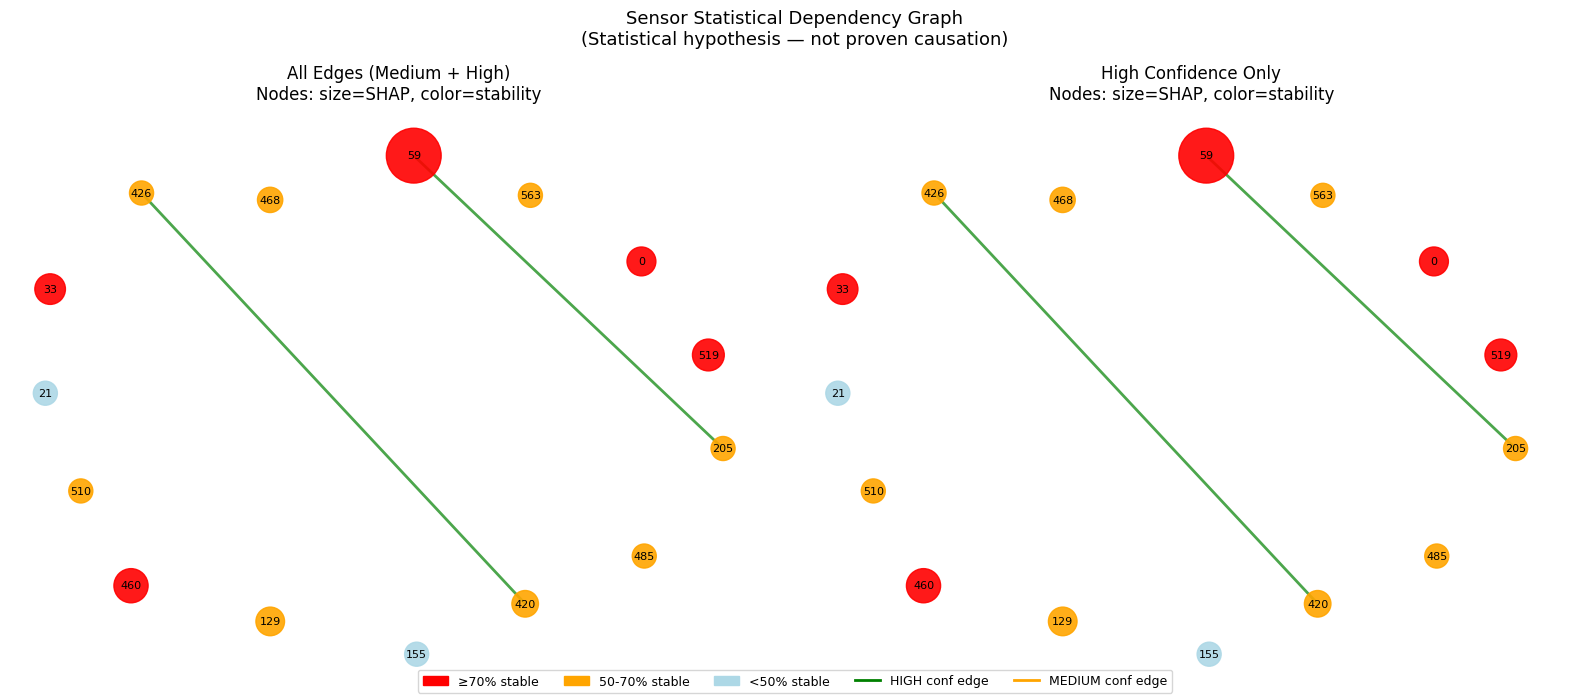

✅ Graph saved


In [8]:
# ============================================================
# RELOAD stability_df then rerun visualization
# ============================================================

stability_df = pd.read_csv(f'{OUTPUT_DIR}/data/p4_bootstrap_stability.csv')

# Now rerun Cell 7 visualization directly below
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

shap_dict = dict(zip(
    top25['sensor'].astype(str),
    top25['mean_shap']
))

for ax, conf_filter, title in zip(
    axes,
    [None, 'HIGH'],
    ['All Edges (Medium + High)', 'High Confidence Only']
):
    G = nx.Graph()
    G.add_nodes_from(stable_sensors)

    if len(consensus_df) > 0:
        edges_to_add = consensus_df if conf_filter is None \
            else consensus_df[consensus_df['confidence'] == conf_filter]

        for _, row in edges_to_add.iterrows():
            G.add_edge(
                str(row['sensor_a']),
                str(row['sensor_b']),
                weight=abs(row['partial_r']),
                confidence=row['confidence']
            )

    pos = nx.spring_layout(G, seed=42, k=2)

    node_sizes = [
        max(300, shap_dict.get(n, 0.001) * 50000)
        for n in G.nodes()
    ]

    stab_dict = dict(zip(
        stability_df['sensor'].astype(str),
        stability_df['stability_pct']
    ))
    node_colors = [
        'red'    if stab_dict.get(n, 0) >= 70
        else 'orange' if stab_dict.get(n, 0) >= 50
        else 'lightblue'
        for n in G.nodes()
    ]

    edge_colors = [
        'green' if d.get('confidence') == 'HIGH' else 'orange'
        for u, v, d in G.edges(data=True)
    ]

    nx.draw_networkx_nodes(
        G, pos, node_size=node_sizes,
        node_color=node_colors, alpha=0.9, ax=ax
    )
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    if G.edges():
        nx.draw_networkx_edges(
            G, pos, edge_color=edge_colors,
            width=2, alpha=0.7, ax=ax
        )

    ax.set_title(f'{title}\nNodes: size=SHAP, color=stability')
    ax.axis('off')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(color='red',       label='≥70% stable'),
    Patch(color='orange',    label='50-70% stable'),
    Patch(color='lightblue', label='<50% stable'),
    Line2D([0],[0], color='green',  linewidth=2, label='HIGH conf edge'),
    Line2D([0],[0], color='orange', linewidth=2, label='MEDIUM conf edge'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=5, fontsize=9)
plt.suptitle(
    'Sensor Statistical Dependency Graph\n'
    '(Statistical hypothesis — not proven causation)',
    fontsize=13
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/plots/p5_dependency_graph.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph saved")

In [9]:
# ============================================================
# STEP 5.6 — SAVE OUTPUTS
# ============================================================

if len(consensus_df) > 0:
    consensus_df.to_csv(
        f'{OUTPUT_DIR}/data/p5_consensus_edges.csv', index=False)
else:
    pd.DataFrame(columns=[
        'sensor_a','sensor_b','partial_r','in_pc','confidence'
    ]).to_csv(f'{OUTPUT_DIR}/data/p5_consensus_edges.csv', index=False)

partial_corr_df.to_csv(
    f'{OUTPUT_DIR}/data/p5_partial_corr_matrix.csv')

pd.DataFrame({
    'sensor':      list(conn_series.index),
    'connections': list(conn_series.values)
}).to_csv(f'{OUTPUT_DIR}/data/p5_sensor_connections.csv', index=False)

print(f"✅ p5_consensus_edges.csv     saved")
print(f"✅ p5_partial_corr_matrix.csv saved")
print(f"✅ p5_sensor_connections.csv  saved")
print(f"\n🚀 PHASE 5 DONE — Ready for Phase 6")
print(f"   Total edges    : {len(consensus_df)}")
if len(consensus_df) > 0:
    print(f"   HIGH conf      : {(consensus_df['confidence']=='HIGH').sum()}")
    print(f"   MEDIUM conf    : {(consensus_df['confidence']=='MEDIUM').sum()}")
    print(f"   Top connected  : {conn_series.index[0]} ({conn_series.iloc[0]} connections)")
print(f"\n   These edges → Phase 6 hypothesis tracing")

✅ p5_consensus_edges.csv     saved
✅ p5_partial_corr_matrix.csv saved
✅ p5_sensor_connections.csv  saved

🚀 PHASE 5 DONE — Ready for Phase 6
   Total edges    : 2
   HIGH conf      : 2
   MEDIUM conf    : 0
   Top connected  : 59 (1 connections)

   These edges → Phase 6 hypothesis tracing
